In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.chdir('/content/gdrive/MyDrive')
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, Convolution1D, Dropout
from keras.optimizers import SGD
from keras.initializers import random_uniform

In [ ]:
dftrain = pd.read_csv('/content/FVthermo.csv')
#df.head()

In [ ]:
##Label and ID represent dataset

In [ ]:
Y=dftrain['Label']
X=dftrain.drop(['Label'],axis=1)

In [ ]:
# Convert all non-numeric values to NaN and then handle them
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Option 1: Drop rows with NaN values
X = X.dropna()

In [ ]:
# Option 2: Fill NaN values with a default value (e.g., 0)
# X = X.fillna(0)

In [ ]:
# Ensure the target labels are aligned with the cleaned features
Y = Y.loc[X.index]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:
# Normalize the feature data
X = X.to_numpy()
Y = Y.to_numpy()
scaler = MinMaxScaler().fit(X)
X = scaler.transform(X)
X = np.nan_to_num(X.astype('float32'))

In [ ]:
# libaray For differnt measure
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import precision_score, matthews_corrcoef, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
##Split Data
from sklearn.metrics import accuracy_score
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from sklearn.manifold import TSNE
from sklearn.datasets import make_moons, make_circles, make_classification
import matplotlib.pyplot as plt

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, precision_score
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)
import numpy as np

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, matthews_corrcoef
)
from sklearn.datasets import make_classification
import numpy as np
import joblib   # for saving and loading model

# ----------------------------
# Generate Dataset (Example)
# ----------------------------
X, Y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=2,
    n_informative=10,
    random_state=42
)

# ----------------------------
# Train Model
# ----------------------------
svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svc.fit(X, Y)

# ----------------------------
# Save Model
# ----------------------------
model_file = "svc_model.pkl"
joblib.dump(svc, model_file)
print(f"Model saved as {model_file}")

# ----------------------------
# Load Model
# ----------------------------
loaded_model = joblib.load(model_file)
print("Model loaded successfully")

# ----------------------------
# Prediction (Self-consistency)
# ----------------------------
Y_pred = loaded_model.predict(X)

# ----------------------------
# Evaluation Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred)
precision = precision_score(Y, Y_pred)
recall = recall_score(Y, Y_pred)

cm = confusion_matrix(Y, Y_pred)

# Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# MCC
mcc = matthews_corrcoef(Y, Y_pred)

# ----------------------------
# Results
# ----------------------------
print("\nSVM Self-Consistency Validation Results:")
print(f"Accuracy: {accuracy * 100:.3f}%")
print(f"F1-Score: {f1 * 100:.3f}%")
print(f"Precision: {precision * 100:.3f}%")
print(f"Sensitivity (Recall): {recall * 100:.3f}%")
print(f"Specificity: {specificity * 100:.3f}%")
print(f"MCC: {mcc:.3f}")

print("\nConfusion Matrix:")
print(cm)

Model saved as svc_model.pkl
Model loaded successfully

SVM Self-Consistency Validation Results:
Accuracy: 97.400%
F1-Score: 97.400%
Precision: 97.595%
Sensitivity (Recall): 97.206%
Specificity: 97.595%
MCC: 0.948

Confusion Matrix:
[[487  12]
 [ 14 487]]


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
# Get decision function scores for ROC Curve on the same dataset (self-consistency)
svc_scores_self_consistency = svc.decision_function(X)  # Use the entire dataset X

In [ ]:
# Calculate ROC Curve
fpr_self_consistency, tpr_self_consistency, _ = roc_curve(Y, svc_scores_self_consistency)  # True labels: Y

In [ ]:
# Calculate AUC for the ROC Curve
roc_auc_self_consistency = auc(fpr_self_consistency, tpr_self_consistency)

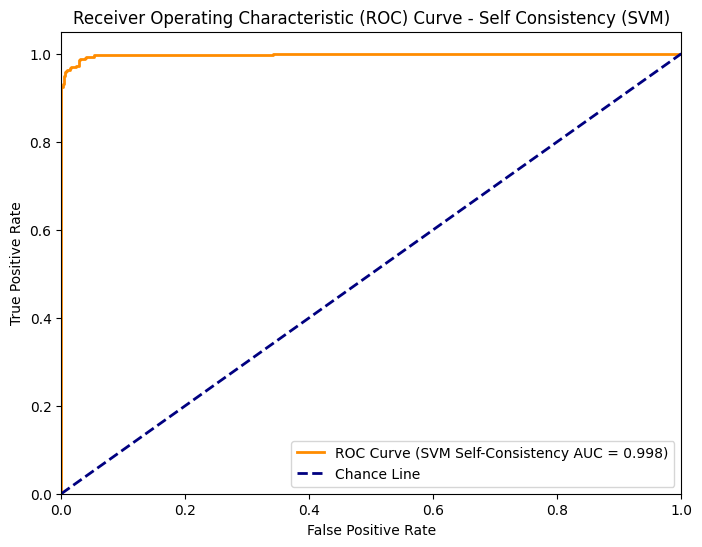

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr_self_consistency, tpr_self_consistency,
    color='darkorange', lw=2,
    label='ROC Curve (SVM Self-Consistency AUC = %0.3f)' % roc_auc_self_consistency
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance Line')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Self Consistency (SVM)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Print AUC
print(f"AUC for SVM Self-Consistency Validation: {roc_auc_self_consistency:.3f}")

AUC for SVM Self-Consistency Validation: 0.998


Model trained and saved (Self-consistency RF)

=== Random Forest Self-Consistency Results ===
Accuracy: 98.728%
Balanced Accuracy: 98.801%
F1 Score (Macro): 98.719%
Precision (Macro): 98.653%
Sensitivity (Recall): 99.607%
Specificity: 97.996%
MCC: 0.975
AUC: 1.000

Confusion Matrix:
[[2396   49]
 [   8 2027]]


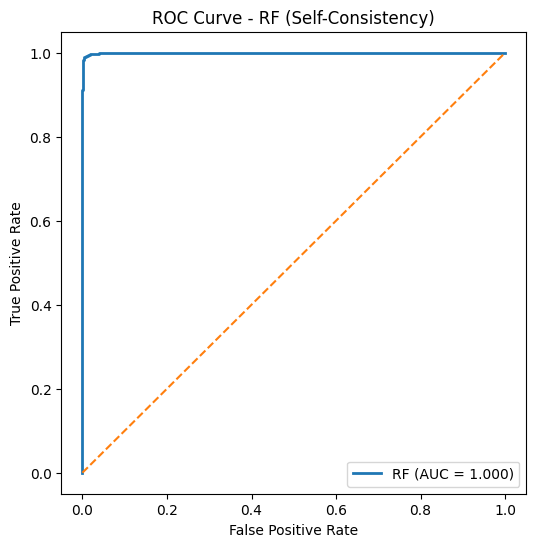

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_curve, auc
)
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

# ----------------------------
# Model file
# ----------------------------
model_file = "rf_selfconsistency.pkl"

# ----------------------------
# Define RF parameters (IMPORTANT)
# ----------------------------
rf_params = {
    "n_estimators": 50,        # number of trees
    "criterion": "entropy",        # or "entropy"
    "max_depth": 10,          # full depth (can control overfitting)
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",     # recommended for classification
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": -1                # use all CPU cores

}

# ----------------------------
# Load OR Train model
# ----------------------------
if os.path.exists(model_file):
    rf = joblib.load(model_file)
    print("Model loaded successfully (Self-consistency RF)")
else:
    rf = RandomForestClassifier(**rf_params)
    rf.fit(X, Y)   # TRAIN on full dataset
    joblib.dump(rf, model_file)
    print("Model trained and saved (Self-consistency RF)")

# ----------------------------
# SELF-CONSISTENCY TEST
# (Train = Test)
# ----------------------------
Y_pred = rf.predict(X)
Y_prob = rf.predict_proba(X)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred)
balanced_acc = balanced_accuracy_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred, average='macro')
precision = precision_score(Y, Y_pred, average='macro')
recall = recall_score(Y, Y_pred, average='macro')
mcc = matthews_corrcoef(Y, Y_pred)

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ROC
fpr, tpr, _ = roc_curve(Y, Y_prob)
roc_auc = auc(fpr, tpr)

# ----------------------------
# Print Results
# ----------------------------
print("\n=== Random Forest Self-Consistency Results ===")
print(f"Accuracy: {accuracy * 100:.3f}%")
print(f"Balanced Accuracy: {balanced_acc * 100:.3f}%")
print(f"F1 Score (Macro): {f1 * 100:.3f}%")
print(f"Precision (Macro): {precision * 100:.3f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.3f}%")
print(f"Specificity: {specificity * 100:.3f}%")
print(f"MCC: {mcc:.3f}")
print(f"AUC: {roc_auc:.3f}")

print("\nConfusion Matrix:")
print(cm)

# ----------------------------
# ROC Plot
# ----------------------------
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, lw=2, label=f'RF (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RF (Self-Consistency)")
plt.legend(loc="lower right")
plt.show()

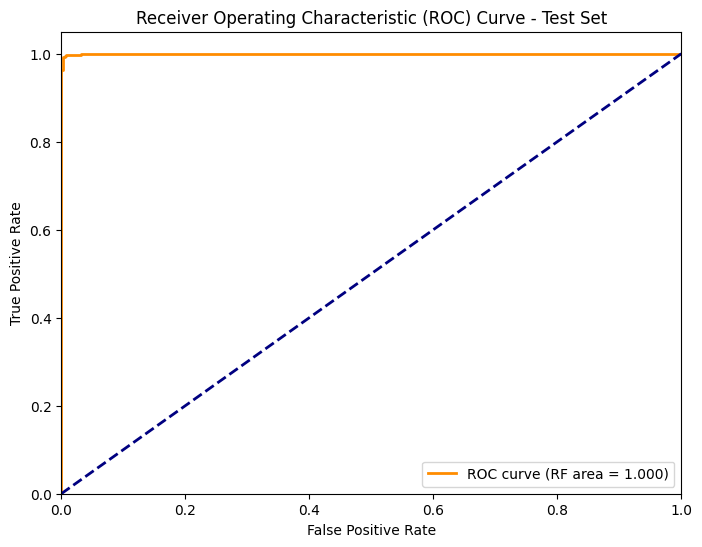

In [ ]:
# Calculate probabilities for ROC Curve on test set
rf_probs_test = rf.predict_proba(X_test)[:, 1]  # Probabilities of positive class (class 1)

# Calculate ROC Curve for test set
fpr_test, tpr_test, _ = roc_curve(Y_test, rf_probs_test)
rf_roc_auc_test = roc_auc_score(Y_test, rf_probs_test)
# Plot ROC Curve for test set
plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='ROC curve (RF area = %0.3f)' % rf_roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()

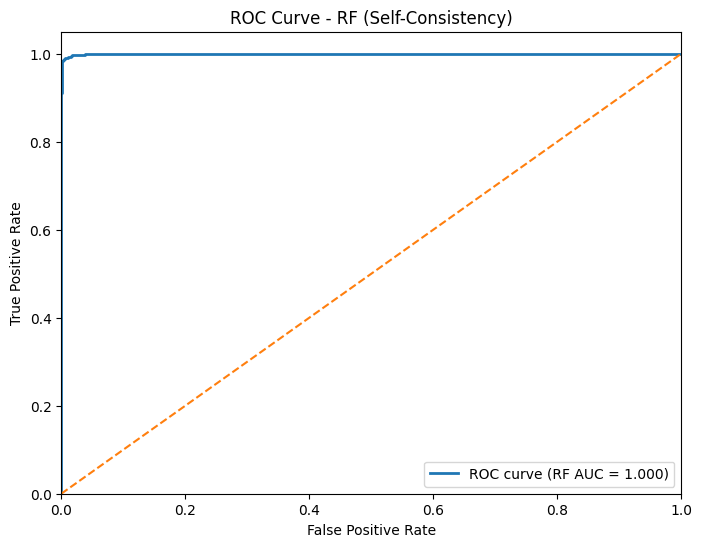

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities (same dataset)
rf_probs = rf.predict_proba(X)[:, 1]

# ROC calculation
fpr, tpr, _ = roc_curve(Y, rf_probs)
roc_auc = roc_auc_score(Y, rf_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label='ROC curve (RF AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RF (Self-Consistency)')
plt.legend(loc="lower right")
plt.show()

Extra Trees model trained and saved

=== Extra Trees Self-Consistency Results ===
Accuracy: 99.441964286%
Balanced Accuracy: 99.488752556%
F1 Score: 99.437812387%
Precision: 99.393203883%
Sensitivity (Recall): 100.000000000%
Specificity: 98.977505112%
MCC: 0.988819103
AUC: 0.999993569

Confusion Matrix:
[[2420   25]
 [   0 2035]]


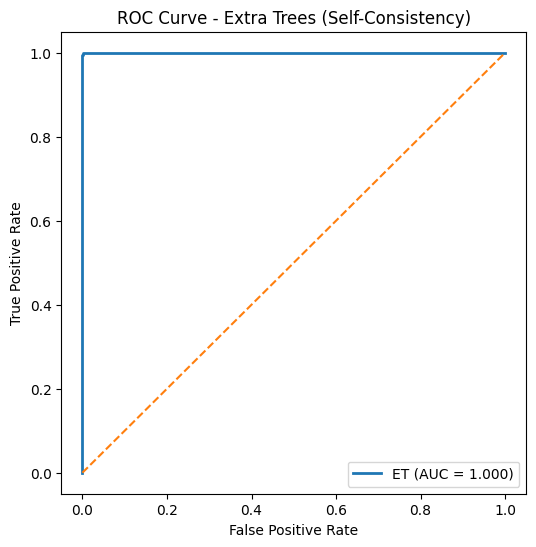

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_auc_score, roc_curve
)
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

# ----------------------------
# Model file
# ----------------------------
model_file = "et_selfconsistency.pkl"

# ----------------------------
# Define Extra Trees parameters
# ----------------------------
et_params = {
    "n_estimators": 50,
    "criterion": "entropy",        # "gini" or "entropy" or "log_loss"
    "max_depth": 16,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "bootstrap": False,         # default for ExtraTrees
    "random_state": 42,
    "n_jobs": -1
}

# ----------------------------
# Load OR Train model
# ----------------------------
if os.path.exists(model_file):
    et = joblib.load(model_file)
    print("Extra Trees model loaded successfully")
else:
    et = ExtraTreesClassifier(**et_params)
    et.fit(X, Y)   # SELF-CONSISTENCY (train = test)
    joblib.dump(et, model_file)
    print("Extra Trees model trained and saved")

# ----------------------------
# SELF-CONSISTENCY PREDICTION
# ----------------------------
Y_pred = et.predict(X)
Y_prob = et.predict_proba(X)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred)
balanced_acc = balanced_accuracy_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred, average='macro')
precision = precision_score(Y, Y_pred, average='macro')
recall = recall_score(Y, Y_pred, average='macro')
mcc = matthews_corrcoef(Y, Y_pred)

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()

# Correct definitions
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# ROC + AUC (correct)
fpr, tpr, _ = roc_curve(Y, Y_prob)
roc_auc = roc_auc_score(Y, Y_prob)

# ----------------------------
# Print Results
# ----------------------------
print("\n=== Extra Trees Self-Consistency Results ===")
print(f"Accuracy: {accuracy * 100:.9f}%")
print(f"Balanced Accuracy: {balanced_acc * 100:.9f}%")
print(f"F1 Score: {f1 * 100:.9f}%")
print(f"Precision: {precision * 100:.9f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.9f}%")
print(f"Specificity: {specificity * 100:.9f}%")
print(f"MCC: {mcc:.9f}")
print(f"AUC: {roc_auc:.9f}")

print("\nConfusion Matrix:")
print(cm)

# ----------------------------
# ROC Curve Plot
# ----------------------------
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, lw=2, label=f'ET (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Extra Trees (Self-Consistency)")
plt.legend(loc="lower right")
plt.show()

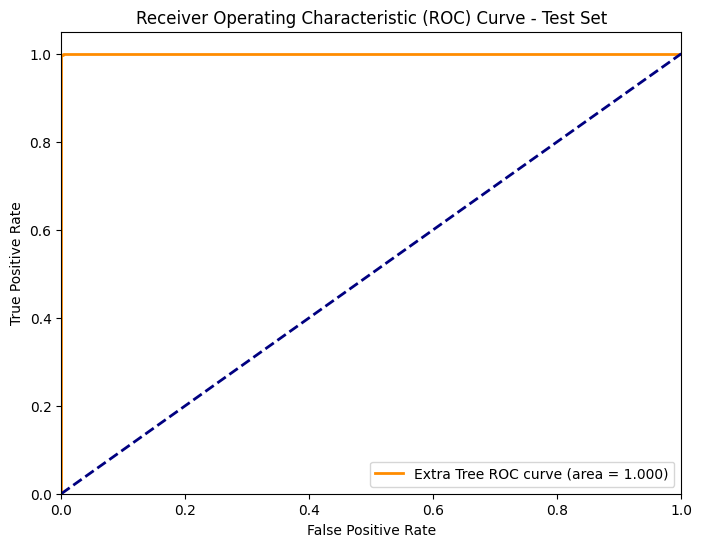

In [ ]:
# Calculate probabilities for ROC Curve on test set
et_probs_test = et.predict_proba(X_test)[:, 1]  # Probabilities of positive class (class 1)

# Calculate ROC Curve for test set
etc_fpr_test, etc_tpr_test, _ = roc_curve(Y_test, et_probs_test)
et_roc_auc_test = roc_auc_score(Y_test, et_probs_test)

# Plot ROC Curve for test set
plt.figure(figsize=(8, 6))
plt.plot(etc_fpr_test, etc_tpr_test, color='darkorange', lw=2, label='Extra Tree ROC curve (area = %0.3f)' % et_roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()


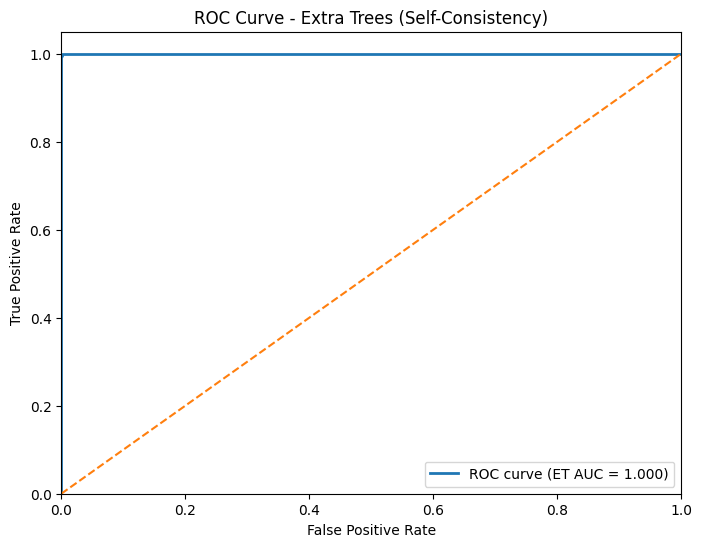

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities on SAME dataset (self-consistency)
et_probs = et.predict_proba(X)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(Y, et_probs)
roc_auc = roc_auc_score(Y, et_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2,
         label='ROC curve (ET AUC = %0.3f)' % roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Extra Trees (Self-Consistency)')

plt.legend(loc="lower right")
plt.show()

LightGBM (LGBM)

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_auc_score
)
import numpy as np
import joblib
import os

# ----------------------------
# Model file
# ----------------------------
model_file = "lgbm_selfconsistency.pkl"

# ----------------------------
# Define LGBM parameters
# ----------------------------
lgbm_params = {

    "n_estimators": 100,
    "learning_rate": 0.05,
    "max_depth": -1,            # -1 means no limit
    "num_leaves": 30,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1
}

# ----------------------------
# Load OR Train model
# ----------------------------
if os.path.exists(model_file):
    lgbm = joblib.load(model_file)
    print("LGBM model loaded successfully")
else:
    lgbm = LGBMClassifier(**lgbm_params)
    lgbm.fit(X, Y)   # SELF-CONSISTENCY (train = test)
    joblib.dump(lgbm, model_file)
    print("LGBM model trained and saved")

# ----------------------------
# SELF-CONSISTENCY PREDICTION
# ----------------------------
Y_pred = lgbm.predict(X)
Y_prob = lgbm.predict_proba(X)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred)
balanced_acc = balanced_accuracy_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred, average='macro')
precision = precision_score(Y, Y_pred, average='macro')
recall = recall_score(Y, Y_pred, average='macro')
mcc = matthews_corrcoef(Y, Y_pred)

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# AUC (correct)
roc_auc = roc_auc_score(Y, Y_prob)

# ----------------------------
# Print Results
# ----------------------------
print("\n=== LGBM Self-Consistency Results ===")
print(f"Accuracy: {accuracy * 100:.9f}%")
print(f"Balanced Accuracy: {balanced_acc * 100:.9f}%")
print(f"F1 Score: {f1 * 100:.9f}%")
print(f"Precision: {precision * 100:.9f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.9f}%")
print(f"Specificity: {specificity * 100:.9f}%")
print(f"MCC: {mcc:.9f}")
print(f"AUC: {roc_auc:.9f}")

print("\nConfusion Matrix:")
print(cm)

[LightGBM] [Info] Number of positive: 2035, number of negative: 2445
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 32026
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454241 -> initscore=-0.183549
[LightGBM] [Info] Start training from score -0.183549
LGBM model trained and saved

=== LGBM Self-Consistency Results ===
Accuracy: 98.191964286%
Balanced Accuracy: 98.240555112%
F1 Score: 98.178931155%
Precision: 98.126911346%
Sensitivity (Recall): 98.771498771%
Specificity: 97.709611452%
MCC: 0.963673994
AUC: 0.998920326

Confusion Matrix:
[[2389   56]
 [  25 2010]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


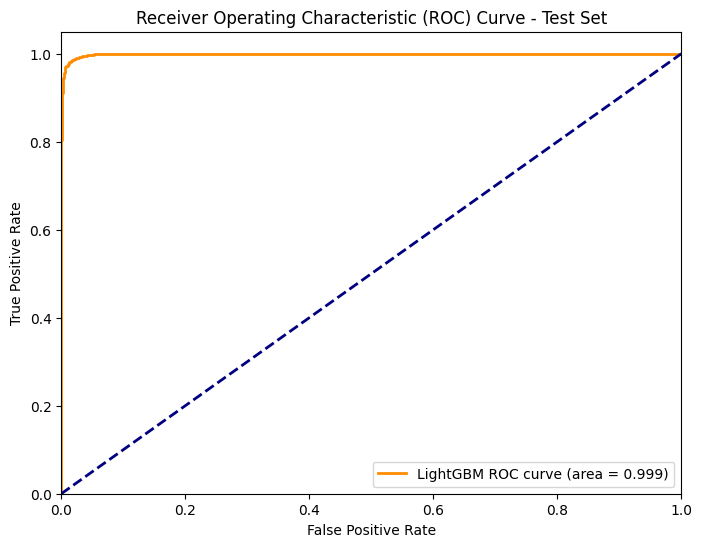

In [ ]:
# ----------------------------
# Calculate probabilities for ROC Curve on test set (LightGBM)
# ----------------------------
lgbm_probs_test = lgbm.predict_proba(X)[:, 1]  # Probabilities of positive class (class 1)

# ----------------------------
# Calculate ROC Curve for test set
# ----------------------------
fpr, tpr, _ = roc_curve(Y, lgbm_probs)
lbgm_roc_auc = roc_auc_score(Y, lgbm_probs)

lgbm_fpr_test, lgbm_tpr_test, _ = roc_curve(Y, lgbm_probs)
lgbm_roc_auc = roc_auc_score(Y, lgbm_probs)

# ----------------------------
# Plot ROC Curve for test set
# ----------------------------
plt.figure(figsize=(8, 6))
plt.plot(lgbm_fpr_test,lgbm_tpr_test,color='darkorange', lw=2,label='LightGBM ROC curve (area = %0.3f)' % lgbm_roc_auc
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set')
plt.legend(loc="lower right")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


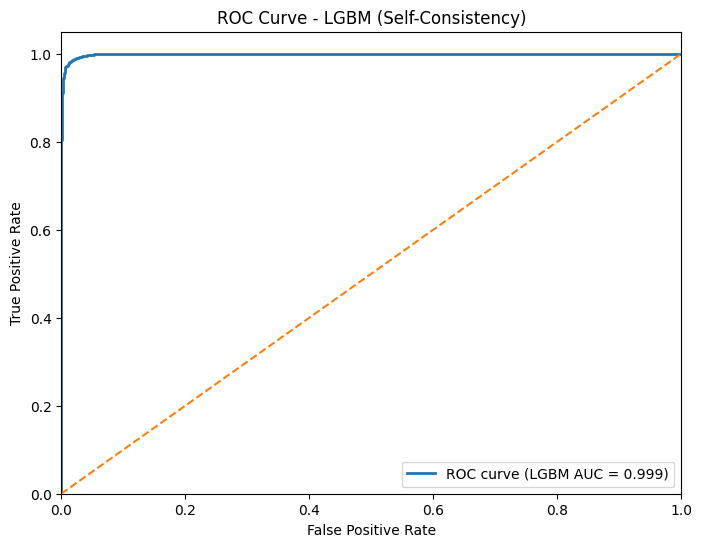

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities (same dataset)
lgbm_probs = lgbm.predict_proba(X)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(Y, lgbm_probs)
lbgm_roc_auc = roc_auc_score(Y, lgbm_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label='ROC curve (LGBM AUC = %0.3f)' % lbgm_roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LGBM (Self-Consistency)')

plt.legend(loc="lower right")
plt.show()

In [ ]:
pip install xgboost lightgbm catboost

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_auc_score
)
import numpy as np
import joblib
import os

# ----------------------------
# Model file
# ----------------------------
model_file = "catboost_selfconsistency.pkl"

# ----------------------------
# Define CatBoost parameters
# ----------------------------
cat_params = {
    "iterations": 100,
    "learning_rate": 0.1,
    "depth": 12,
    "loss_function": "Logloss",   # for binary classification
    "eval_metric": "AUC",
    "random_seed": 42,
    "verbose": 0
}

# ----------------------------
# Load OR Train model
# ----------------------------
if os.path.exists(model_file):
    cat = joblib.load(model_file)
    print("CatBoost model loaded successfully")
else:
    cat = CatBoostClassifier(**cat_params)
    cat.fit(X, Y)
    joblib.dump(cat, model_file)
    print("CatBoost model trained and saved")

# ----------------------------
# SELF-CONSISTENCY PREDICTION
# ----------------------------
Y_pred = cat.predict(X)
Y_prob = cat.predict_proba(X)[:, 1]

# ----------------------------
# Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred)
balanced_acc = balanced_accuracy_score(Y, Y_pred)
f1 = f1_score(Y, Y_pred, average='macro')
precision = precision_score(Y, Y_pred, average='macro')
recall = recall_score(Y, Y_pred, average='macro')
mcc = matthews_corrcoef(Y, Y_pred)

# Confusion Matrix
cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# AUC
roc_auc = roc_auc_score(Y, Y_prob)

# ----------------------------
# Print Results
# ----------------------------
print("\n=== CatBoost Self-Consistency Results ===")
print(f"Accuracy: {accuracy * 100:.9f}%")
print(f"Balanced Accuracy: {balanced_acc * 100:.9f}%")
print(f"F1 Score: {f1 * 100:.9f}%")
print(f"Precision: {precision * 100:.9f}%")
print(f"Sensitivity (Recall): {sensitivity * 100:.9f}%")
print(f"Specificity: {specificity * 100:.9f}%")
print(f"MCC: {mcc:.9f}")
print(f"AUC: {roc_auc:.9f}")

print("\nConfusion Matrix:")
print(cm)

CatBoost model trained and saved

=== CatBoost Self-Consistency Results ===
Accuracy: 99.709821429%
Balanced Accuracy: 99.701190315%
F1 Score: 99.707334198%
Precision: 99.713569811%
Sensitivity (Recall): 99.606879607%
Specificity: 99.795501022%
MCC: 0.994147594
AUC: 0.999972465

Confusion Matrix:
[[2440    5]
 [   8 2027]]


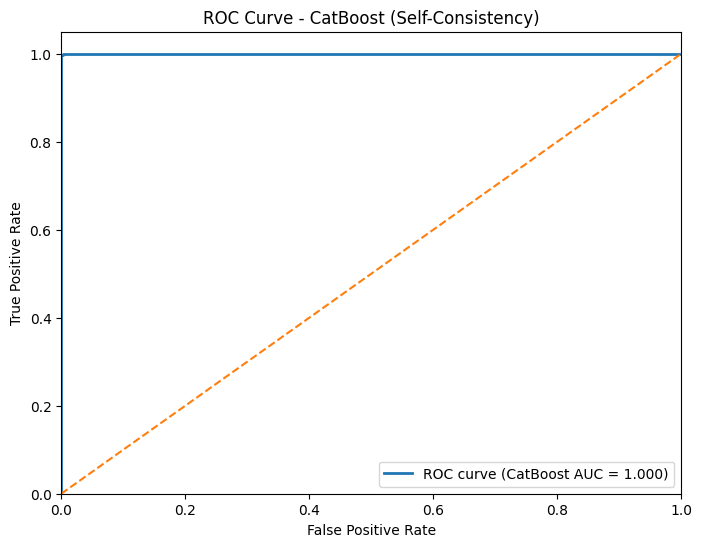

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities (same dataset)
cat_probs = cat.predict_proba(X)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(Y, cat_probs)
cat_roc_auc = roc_auc_score(Y, cat_probs)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label='ROC curve (CatBoost AUC = %0.3f)' % cat_roc_auc)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CatBoost (Self-Consistency)')

plt.legend(loc="lower right")
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

In [ ]:
# ----------------------------
# Step 0: Model file
# ----------------------------
model_file = "cnn1d_selfconsistency.h5"


In [ ]:
# ----------------------------
# Step 2: Load OR Build Model
# ----------------------------
if os.path.exists(model_file):
    CNN1D = load_model(model_file)
    print("CNN1D model loaded successfully")
else:
    CNN1D = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    CNN1D.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # ----------------------------
    # Step 3: Train the Model (Self-Consistency)
    # ----------------------------
    CNN1D.fit(X, Y, epochs=100, batch_size=32, verbose=1)

    # Save the model
    CNN1D.save(model_file)
    print("CNN1D model trained and saved")

CNN1D model loaded successfully


In [ ]:
# Step 5: Predict on the Same Dataset
Y_pred_probs = CNN1D.predict(X).ravel()
Y_pred = (Y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'dense_6' is incompatible with the layer: expected axis -1 of input shape to have value 2176, but received input with shape (32, 512)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 50), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
# Step 6: Compute Metrics
accuracy = accuracy_score(Y, Y_pred) * 100
balanced_acc = balanced_accuracy_score(Y, Y_pred) * 100
f1 = f1_score(Y, Y_pred) * 100
precision = precision_score(Y, Y_pred) * 100
recall = recall_score(Y, Y_pred) * 100  # Sensitivity
cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0.0
mcc = matthews_corrcoef(Y, Y_pred)
roc_auc = roc_auc_score(Y, Y_pred_probs) * 100

In [ ]:
# Step 7: Print Metrics
print("CNN1D Self-Consistency Results:")
print(f"Accuracy: {accuracy:.9f}%")
print(f"Balanced Accuracy: {balanced_acc:.9f}%")
print(f"F1 Score: {f1:.9f}%")
print(f"Precision: {precision:.9f}%")
print(f"Sensitivity (Recall): {recall:.9f}%")
print(f"Specificity: {specificity:.9f}%")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.9f}")
print(f"AUC: {roc_auc:.9f}%")
print("Confusion Matrix:")
print(cm)

CNN1D Self-Consistency Results:
Accuracy: 97.700000000%
Balanced Accuracy: 97.701963231%
F1 Score: 97.697697698%
Precision: 98.189134809%
Sensitivity (Recall): 97.211155378%
Specificity: 98.192771084%
Matthews Correlation Coefficient (MCC): 0.954048805
AUC: 99.587593401%
Confusion Matrix:
[[489   9]
 [ 14 488]]


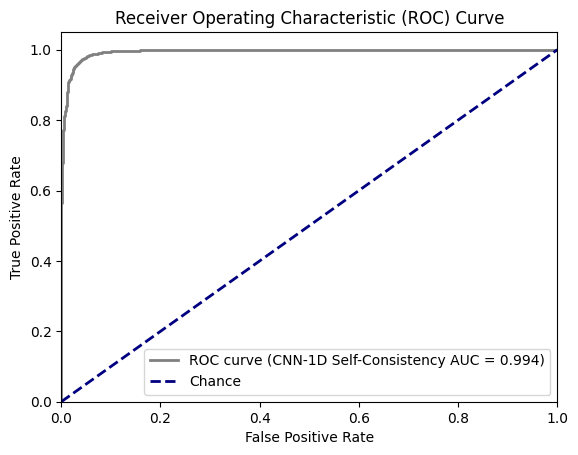

0.9943743185460977


In [ ]:
#plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)
plt.plot(cnn_model_fpr, cnn_model_tpr, color='Grey', lw=2, label='ROC curve (CNN-1D Self-Consistency AUC = %0.3f)' % cnn_model_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
#plt.plot(lstm_fpr, lstm_tpr, marker='.', label='LSTM' % lstm_auc)
print(cnn_model_auc)

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score, roc_curve
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import os
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score, roc_curve
)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ----------------------------
# Step 0: Model file
# ----------------------------
model_file = "mlp_selfconsistency.h5"

# ----------------------------
# Step 1: Initialize Dataset
# ----------------------------
X, Y = make_classification(
    n_samples=1000, n_features=50, n_classes=2, n_informative=35,
    flip_y=0.05, random_state=42
)

# ----------------------------
# Step 2: Load OR Build Model
# ----------------------------
if os.path.exists(model_file):
    MLP = load_model(model_file)
    print("MLP model loaded successfully")
else:
    MLP = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    MLP.compile(optimizer=Adam(learning_rate=0.001),
                loss='binary_crossentropy',
                metrics=['accuracy'])

    # ----------------------------
    # Step 3: Train the Model (Self-Consistency)
    # ----------------------------
    MLP.fit(X, Y, epochs=50, batch_size=32, verbose=1)

    # Save the model
    MLP.save(model_file)
    print("MLP model trained and saved")

# ----------------------------
# Step 4: Predict on Same Dataset
# ----------------------------
Y_pred_probs = MLP.predict(X).ravel()
Y_pred = (Y_pred_probs > 0.5).astype(int)

# ----------------------------
# Step 5: Compute Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred) * 100
balanced_acc = balanced_accuracy_score(Y, Y_pred) * 100
f1 = f1_score(Y, Y_pred) * 100
precision = precision_score(Y, Y_pred) * 100
recall = recall_score(Y, Y_pred) * 100  # Sensitivity

cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0.0

mcc = matthews_corrcoef(Y, Y_pred)
roc_auc = roc_auc_score(Y, Y_pred_probs) * 100

# ----------------------------
# Step 6: Print Metrics
# ----------------------------
print("\nMLP Self-Consistency Results:")
print(f"Accuracy: {accuracy:.9f}%")
print(f"Balanced Accuracy: {balanced_acc:.9f}%")
print(f"F1 Score: {f1:.9f}%")
print(f"Precision: {precision:.9f}%")
print(f"Sensitivity (Recall): {recall:.9f}%")
print(f"Specificity: {specificity:.9f}%")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.9f}")
print(f"AUC: {roc_auc:.9f}%")
print("Confusion Matrix:")
print(cm)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5350 - loss: 1.3107
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5240 - loss: 1.0622
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5540 - loss: 0.8462
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5940 - loss: 0.7395
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6230 - loss: 0.7053
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6190 - loss: 0.7083
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6130 - loss: 0.6808
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6500 - loss: 0.6611
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6800 - loss: 0.6246
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6780 - loss: 0.6249
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7140 - loss: 0.5568
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7630 - loss: 0.5026


MLP model trained and saved
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

MLP Self-Consistency Results:
Accuracy: 97.700000000%
Balanced Accuracy: 97.701963231%
F1 Score: 97.697697698%
Precision: 98.189134809%
Sensitivity (Recall): 97.211155378%
Specificity: 98.192771084%
Matthews Correlation Coefficient (MCC): 0.954048805
AUC: 99.587593401%
Confusion Matrix:
[[489   9]
 [ 14 488]]


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Get predicted probabilities for the positive class (class 1)
mlp_probs = MLP.predict(X).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# Calculate ROC AUC
mlp_auc = roc_auc_score(Y, mlp_probs)

In [ ]:
# Compute ROC Curve
mlp_fpr, mlp_tpr, thresholds = roc_curve(Y, mlp_probs)

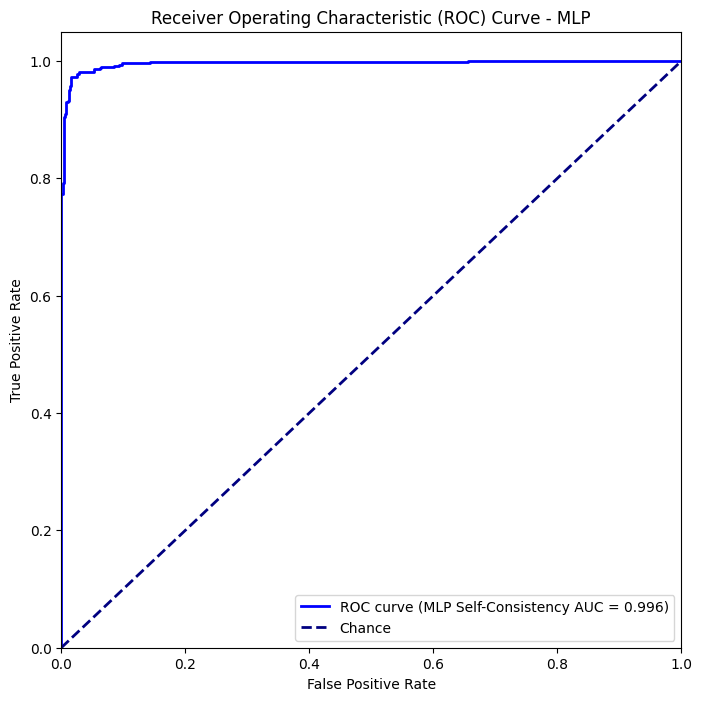

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(8, 8))
plt.plot(mlp_fpr, mlp_tpr, color='blue', lw=2, label='ROC curve (MLP Self-Consistency AUC = %0.3f)' % mlp_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - MLP')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Print AUC
print("AUC for MLP model: %.3f" % mlp_auc)

AUC for MLP model: 0.996


In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score, roc_curve
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import os
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, matthews_corrcoef, roc_auc_score, roc_curve
)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ----------------------------
# Step 0: Model file
# ----------------------------
model_file = "lstm_selfconsistency.h5"

# ----------------------------
# Step 1: Ensure X, Y are defined
# X must have shape: (samples, timesteps, features)
# Example if needed:
# X = np.random.rand(1000, 50, 1)
# Y = np.random.randint(0, 2, size=(1000,))
# ----------------------------

# ----------------------------
# Step 2: Load OR Build Model
# ----------------------------
if os.path.exists(model_file):
    Lstm_model = load_model(model_file)
    print("LSTM model loaded successfully")
else:
    Lstm_model = Sequential([
        LSTM(64, activation='tanh', input_shape=(153, 1)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    Lstm_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    # ----------------------------
    # Step 3: Train the Model (Self-Consistency)
    # ----------------------------
    Lstm_model.fit(X, Y, epochs=100, batch_size=32, verbose=1)

    # Save the model
    Lstm_model.save(model_file)
    print("LSTM model trained and saved")

# ----------------------------
# Step 4: Predict on Same Dataset
# ----------------------------
Y_pred_probs = Lstm_model.predict(X).ravel()
Y_pred = (Y_pred_probs > 0.5).astype(int)

# ----------------------------
# Step 5: Compute Metrics
# ----------------------------
accuracy = accuracy_score(Y, Y_pred) * 100
balanced_acc = balanced_accuracy_score(Y, Y_pred) * 100
f1 = f1_score(Y, Y_pred) * 100
precision = precision_score(Y, Y_pred) * 100
recall = recall_score(Y, Y_pred) * 100  # Sensitivity

cm = confusion_matrix(Y, Y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = (tn / (tn + fp)) * 100 if (tn + fp) > 0 else 0.0

mcc = matthews_corrcoef(Y, Y_pred)
roc_auc = roc_auc_score(Y, Y_pred_probs) * 100

# ----------------------------
# Step 6: Print Metrics
# ----------------------------
print("\nLSTM Self-Consistency Results:")
print(f"Accuracy: {accuracy:.9f}%")
print(f"Balanced Accuracy: {balanced_acc:.9f}%")
print(f"F1 Score: {f1:.9f}%")
print(f"Precision: {precision:.9f}%")
print(f"Sensitivity (Recall): {recall:.9f}%")
print(f"Specificity: {specificity:.9f}%")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.9f}")
print(f"AUC: {roc_auc:.9f}%")
print("Confusion Matrix:")
print(cm)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.5800 - loss: 0.6758
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6830 - loss: 0.6203
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6690 - loss: 0.6237
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6930 - loss: 0.6021
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6900 - loss: 0.5997
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7010 - loss: 0.5842
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7040 - loss: 0.5888
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6990 - loss: 0.5840
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7050 - loss: 0.5719
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7150 - loss: 0.5710
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6930 - loss: 0.5860
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy:

LSTM model trained and saved
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step

LSTM Self-Consistency Results:
Accuracy: 97.000000000%
Balanced Accuracy: 97.003952063%
F1 Score: 96.981891348%
Precision: 97.967479675%
Sensitivity (Recall): 96.015936255%
Specificity: 97.991967871%
Matthews Correlation Coefficient (MCC): 0.940191873
AUC: 99.229987680%
Confusion Matrix:
[[488  10]
 [ 20 482]]


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Get predicted probabilities for the positive class (class 1) from the LSTM model
lstm_probs = Lstm_model.predict(X).flatten()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [ ]:
# Calculate ROC AUC
lstm_auc = roc_auc_score(Y, lstm_probs)

In [ ]:
# Compute ROC Curve
lstm_fpr, lstm_tpr, thresholds = roc_curve(Y, lstm_probs)

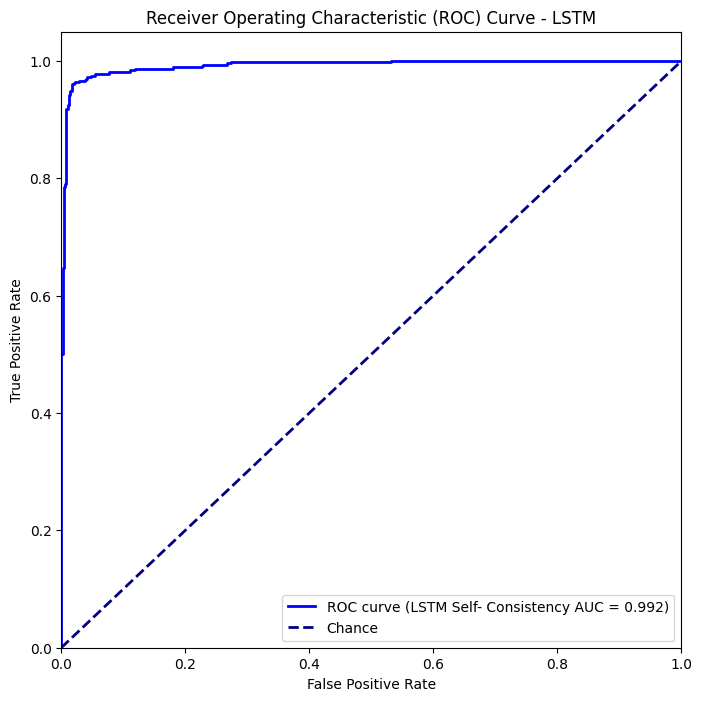

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(8, 8))
plt.plot(lstm_fpr, lstm_tpr, color='blue', lw=2, label='ROC curve (LSTM Self- Consistency AUC = %0.3f)' % lstm_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LSTM')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Print AUC
print("AUC for LSTM model: %.3f" % lstm_auc)

AUC for LSTM model: 0.999


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

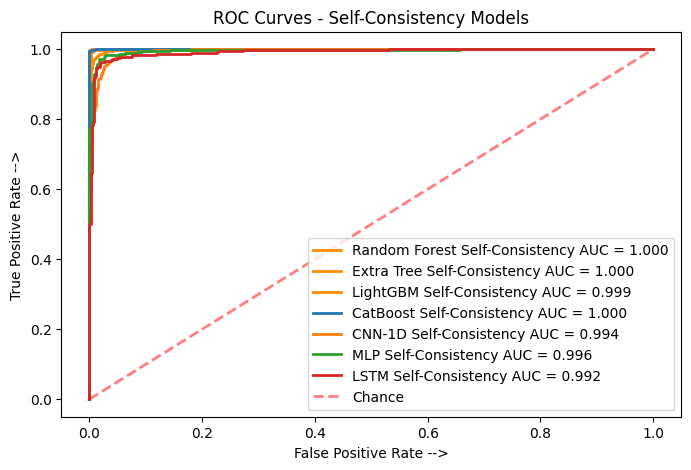

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# ----------------------------
# SVM
# ----------------------------
# plt.plot(fpr_self_consistency, tpr_self_consistency,
#          lw=2, label='SVM Self-Consistency AUC = %0.3f' % roc_auc_self_consistency)

# ----------------------------
# Random Forest
# ----------------------------
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='Random Forest Self-Consistency AUC = %0.3f' % rf_roc_auc_test)

# ----------------------------
# Extra Trees
# ----------------------------
plt.plot(etc_fpr_test, etc_tpr_test, color='darkorange', lw=2, label='Extra Tree Self-Consistency AUC = %0.3f' % et_roc_auc_test)

# ----------------------------
# LGBM
# ----------------------------
plt.plot(lgbm_fpr_test,lgbm_tpr_test,color='darkorange', lw=2,label='LightGBM Self-Consistency AUC = %0.3f' % lgbm_roc_auc)

# ----------------------------
# CatBoost
# ----------------------------
# Plot
plt.plot(fpr, tpr, lw=2, label='CatBoost Self-Consistency AUC = %0.3f' % cat_roc_auc)
# ----------------------------
# CNN, MLP, LSTM
# ----------------------------
plt.plot(cnn_model_fpr, cnn_model_tpr, lw=2, label='CNN-1D Self-Consistency AUC = %0.3f' % cnn_model_auc)
plt.plot(mlp_fpr, mlp_tpr, lw=2, label='MLP Self-Consistency AUC = %0.3f' % mlp_auc)
plt.plot(lstm_fpr, lstm_tpr, lw=2, label='LSTM Self-Consistency AUC = %0.3f' % lstm_auc)

# ----------------------------
# Chance line
# ----------------------------
plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')
plt.title('ROC Curves - Self-Consistency Models')
plt.legend(loc="lower right", fontsize=10)
plt.show()

In [ ]:
import numpy as np

# Load transformer ROC
data = np.load("transformer_self-consistency_roc_data.npz")
fpr_transformer = data['fpr']
tpr_transformer = data['tpr']
auc_transformer = data['auc']

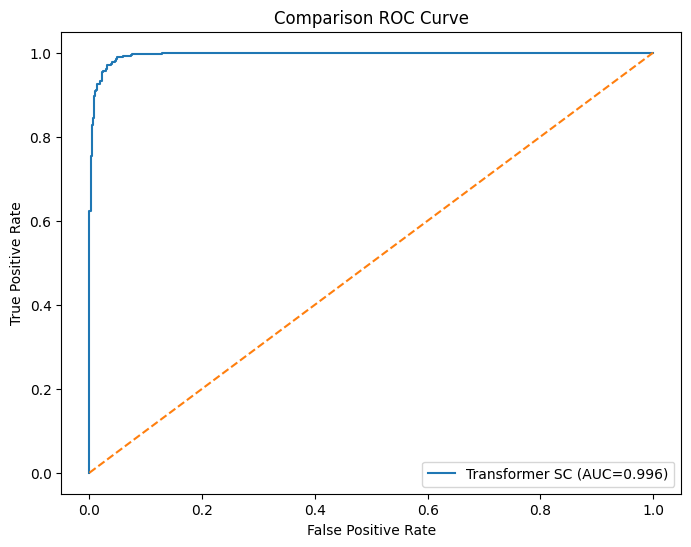

In [ ]:
plt.figure(figsize=(8, 6))

# Example: Random Forest


# 🔥 Transformer (your saved one)
plt.plot(fpr_transformer, tpr_transformer,
         label=f'Transformer SC (AUC={auc_transformer:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparison ROC Curve')
plt.legend()
plt.show()

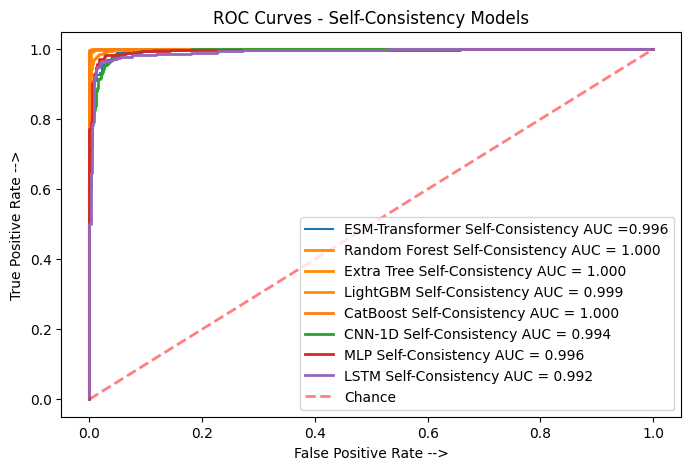

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# ----------------------------
# SVM
# ----------------------------
# plt.plot(fpr_self_consistency, tpr_self_consistency,
#          lw=2, label='SVM Self-Consistency AUC = %0.3f' % roc_auc_self_consistency)





# ----------------------------
# Transfomer-ESM
# ----------------------------
plt.plot(fpr_transformer, tpr_transformer,     label=f'ESM-Transformer Self-Consistency AUC ={auc_transformer:.3f}')


# ----------------------------
# Random Forest
# ----------------------------
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label='Random Forest Self-Consistency AUC = %0.3f' % rf_roc_auc_test)

# ----------------------------
# Extra Trees
# ----------------------------
plt.plot(etc_fpr_test, etc_tpr_test, color='darkorange', lw=2, label='Extra Tree Self-Consistency AUC = %0.3f' % et_roc_auc_test)

# ----------------------------
# LGBM
# ----------------------------
plt.plot(lgbm_fpr_test,lgbm_tpr_test,color='darkorange', lw=2,label='LightGBM Self-Consistency AUC = %0.3f' % lgbm_roc_auc)

# ----------------------------
# CatBoost
# ----------------------------
# Plot
plt.plot(fpr, tpr, lw=2, label='CatBoost Self-Consistency AUC = %0.3f' % cat_roc_auc)
# ----------------------------
# CNN, MLP, LSTM
# ----------------------------
plt.plot(cnn_model_fpr, cnn_model_tpr, lw=2, label='CNN-1D Self-Consistency AUC = %0.3f' % cnn_model_auc)
plt.plot(mlp_fpr, mlp_tpr, lw=2, label='MLP Self-Consistency AUC = %0.3f' % mlp_auc)
plt.plot(lstm_fpr, lstm_tpr, lw=2, label='LSTM Self-Consistency AUC = %0.3f' % lstm_auc)

# ----------------------------
# Chance line
# ----------------------------
plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')
plt.title('ROC Curves - Self-Consistency Models')
plt.legend(loc="lower right", fontsize=10)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Load saved ROC data for all models
# ----------------------------

# Random Forest
rf_fpr = np.load("model_outputs/rf_fpr.npy")
rf_tpr = np.load("model_outputs/rf_tpr.npy")
rf_auc = np.load("model_outputs/rf_auc.npy")[0]

# Extra Trees
et_fpr = np.load("model_outputs/et_fpr.npy")
et_tpr = np.load("model_outputs/et_tpr.npy")
et_auc = np.load("model_outputs/et_auc.npy")[0]

# LightGBM
lgbm_fpr = np.load("model_outputs/lgbm_fpr.npy")
lgbm_tpr = np.load("model_outputs/lgbm_tpr.npy")
lgbm_auc = np.load("model_outputs/lgbm_auc.npy")[0]

# CatBoost
cat_fpr = np.load("model_outputs/catboost_fpr.npy")
cat_tpr = np.load("model_outputs/catboost_tpr.npy")
cat_auc = np.load("model_outputs/catboost_auc.npy")[0]

# CNN-1D
cnn_fpr = np.load("model_outputs/cnn_fpr.npy")
cnn_tpr = np.load("model_outputs/cnn_tpr.npy")
cnn_auc = np.load("model_outputs/cnn_auc.npy")[0]

# MLP
mlp_fpr = np.load("model_outputs/mlp_fpr.npy")
mlp_tpr = np.load("model_outputs/mlp_tpr.npy")
mlp_auc = np.load("model_outputs/mlp_auc.npy")[0]

# LSTM
lstm_fpr = np.load("model_outputs/lstm_fpr.npy")
lstm_tpr = np.load("model_outputs/lstm_tpr.npy")
lstm_auc = np.load("model_outputs/lstm_auc.npy")[0]

# Transformer
trans_fpr = np.load("model_outputs/transformer_fpr.npy")
trans_tpr = np.load("model_outputs/transformer_tpr.npy")
trans_auc = np.load("model_outputs/transformer_auc.npy")[0]

# ----------------------------
# Plot ROC Curves
# ----------------------------
plt.figure(figsize=(10,8))

plt.plot(rf_fpr, rf_tpr, lw=2, label=f'Random Forest AUC = {rf_auc:.3f}')
plt.plot(et_fpr, et_tpr, lw=2, label=f'Extra Trees AUC = {et_auc:.3f}')
plt.plot(lgbm_fpr, lgbm_tpr, lw=2, label=f'LightGBM AUC = {lgbm_auc:.3f}')
plt.plot(cat_fpr, cat_tpr, lw=2, label=f'CatBoost AUC = {cat_auc:.3f}')
plt.plot(cnn_fpr, cnn_tpr, lw=2, label=f'CNN-1D AUC = {cnn_auc:.3f}')
plt.plot(mlp_fpr, mlp_tpr, lw=2, label=f'MLP AUC = {mlp_auc:.3f}')
plt.plot(lstm_fpr, lstm_tpr, lw=2, label=f'LSTM AUC = {lstm_auc:.3f}')
plt.plot(trans_fpr, trans_tpr, lw=2, label=f'Transformer AUC = {trans_auc:.3f}')

# Chance line
plt.plot([0,1], [0,1], linestyle='--', lw=2, color='r', alpha=0.5, label='Chance')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Self-Consistency Models (Offline)")
plt.legend(loc="lower right", fontsize=10)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'model_outputs/rf_fpr.npy'

In [ ]:
import numpy as np
import os

# Create folder if not exists
os.makedirs("model_outputs", exist_ok=True)

# Example: Random Forest
np.save("model_outputs/rf_Y_pred.npy", Y_pred_rf)
np.save("model_outputs/rf_Y_prob.npy", Y_prob_rf)

# Extra Trees
np.save("model_outputs/et_Y_pred.npy", Y_pred_et)
np.save("model_outputs/et_Y_prob.npy", Y_prob_et)

# LGBM
np.save("model_outputs/lgbm_Y_pred.npy", Y_pred_lgbm)
np.save("model_outputs/lgbm_Y_prob.npy", Y_prob_lgbm)

# CatBoost
np.save("model_outputs/catboost_Y_pred.npy", Y_pred_cat)
np.save("model_outputs/catboost_Y_prob.npy", Y_prob_cat)

# CNN-1D
np.save("model_outputs/cnn_Y_pred.npy", Y_pred_cnn)
np.save("model_outputs/cnn_Y_prob.npy", Y_prob_cnn)

# MLP
np.save("model_outputs/mlp_Y_pred.npy", Y_pred_mlp)
np.save("model_outputs/mlp_Y_prob.npy", Y_prob_mlp)

# LSTM
np.save("model_outputs/lstm_Y_pred.npy", Y_pred_lstm)
np.save("model_outputs/lstm_Y_prob.npy", Y_prob_lstm)

print("All model predictions and probabilities saved as .npy files.")

NameError: name 'rf_roc_auc' is not defined

<Figure size 1000x800 with 0 Axes>